In [2]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt

In [3]:
def load_data(path):
    data = np.loadtxt(path, usecols=range(8))
    t = data[:,0].reshape(-1,1)
    x = data[:,1:]
    return t, x

In [4]:
def normalize_data(x):
    mu = np.mean(x, axis=0)
    sig = np.std(x, axis=0, ddof=0)
    
    x_n = (x - mu) / sig
    
    return x_n

In [5]:
def split_train_test(x, t, n_train=100):
    x_train, t_train = x[:n_train], t[:n_train]
    x_test, t_test = x[n_train:], t[n_train:]
    return x_train, t_train, x_test, t_test

In [6]:
def design_matrix_polynomial(x, degree):
    N, D = x.shape
    data = [np.ones((N, 1))]
    for k in range(1, degree + 1):
        data.append(x ** k)
    phi = np.hstack(data)
    return phi

In [7]:
def design_matrix_gaussian(X, centers, s):
    N = X.shape[0]
    M = centers.shape[0]
    Phi = np.ones((N, 1 + M))
    for j in range(M):
        diff = X - centers[j:j+1, :]
        norms2 = np.sum(diff**2, axis=1)
        Phi[:, 1+j] = np.exp(-norms2 / (2*(s**2)))
    return Phi

In [8]:
def ols_solution(Phi, t):
    # w = (Phi^T@Phi)^{-1}@(Phi^T@t)
    a = Phi.T.dot(Phi)
    b = Phi.T.dot(t)
    w = np.linalg.solve(a, b)

    return w

In [9]:
def ridge_solution(Phi, t, lam):
    # w = (Phi^T Phi + lam I)^{-1} Phi^T t, do not regularize bias -> I[0,0]=0
    D = Phi.shape[1]
    A = Phi.T.dot(Phi)
    reg = lam * np.eye(D)
    reg[0,0] = 0.0
    w = np.linalg.solve(A + reg, Phi.T.dot(t))
    return w

In [10]:
def predict(Phi, w):

    y_pred = Phi.dot(w)
    return y_pred.flatten()

In [11]:
def visualize_1d(x_n, t_n, degree, w, x_train_idx=100):
    x_train = x_n[:x_train_idx]
    t_train = t_n[:x_train_idx]
    x_test  = x_n[x_train_idx:]
    t_test  = t_n[x_train_idx:]

    x_ev = np.arange(np.min(x_n), np.max(x_n), 0.1).reshape(-1, 1)

    Phi_ev = np.ones((x_ev.shape[0], 1))
    
    for k in range(1, degree + 1):
        Phi_ev = np.hstack((Phi_ev, x_ev ** k))

    y_ev = Phi_ev.dot(w)

    plt.figure(figsize=(8, 6))
    plt.plot(x_ev, y_ev, 'r.-', label='Model prediction')
    plt.plot(x_train, t_train, 'g.', label='Training data')
    plt.plot(x_test, t_test, 'bo', label='Test data')
    plt.title(f'Fit with degree {degree} polynomial', fontsize=14)
    plt.xlabel('Normalized feature value')
    plt.ylabel('Target (normalized mpg)')
    plt.legend()
    plt.grid(True)
    plt.show()

In [12]:
def rms_error(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))   

# main

In [13]:
    # 1) Load and normalize data
path = 'HW1_Regression_code  datasets/a1_code/auto-mpg.data'
t, x = load_data(path)
x_n = normalize_data(x)
t_n = normalize_data(t)

    # 2) Split: first 100 rows
x_train, t_train, x_test, t_test = split_train_test(x_n, t_n, 100)


In [14]:
    # 3) Run polynomial basis experiments (degrees 1..10) without regularization
for i in range(1,11):
    phi_train = design_matrix_polynomial(x_train, i)
    phi_test = design_matrix_polynomial(x_test, i)

    w = ols_solution(phi_train, t_train)
    
    t_pred = predict(phi_test, w)
    error = rms_error(t_test, t_pred)
    # 
    # t_pred = predict(phi_train, w)
    # error = rms_error(t_train, t_pred)
    
    print(f'RMS Error for {i} polynomial: {error}')

RMS Error for 1 polynomial: 1.3330401048634906
RMS Error for 2 polynomial: 2.3582098783814267
RMS Error for 3 polynomial: 22.16130047514622
RMS Error for 4 polynomial: 1.5171478101021507
RMS Error for 5 polynomial: 1.8783916547581816
RMS Error for 6 polynomial: 8.023161352486376
RMS Error for 7 polynomial: 5.139905906965496
RMS Error for 8 polynomial: 4.495091390704863
RMS Error for 9 polynomial: 76.94124321948817
RMS Error for 10 polynomial: 812.8537993317476


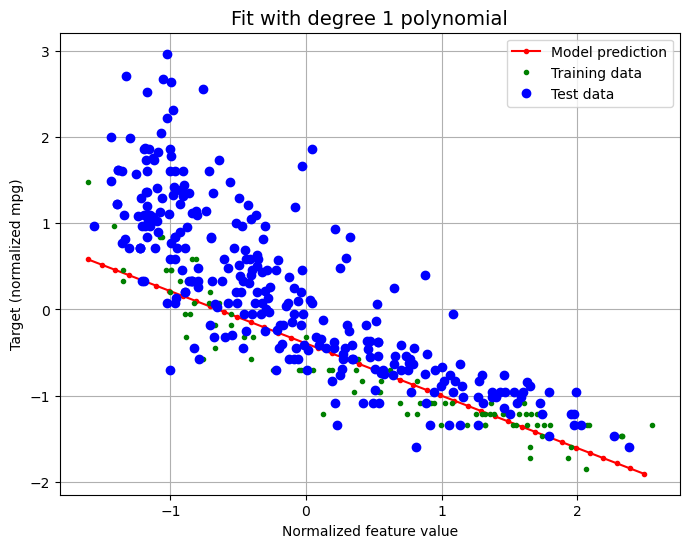

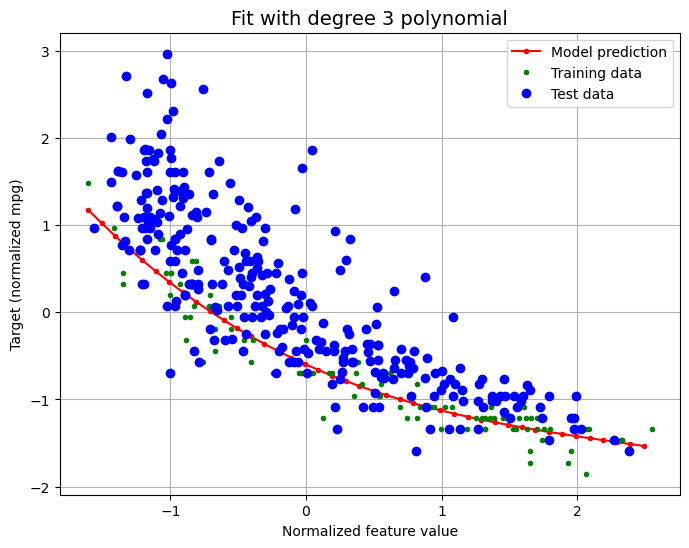

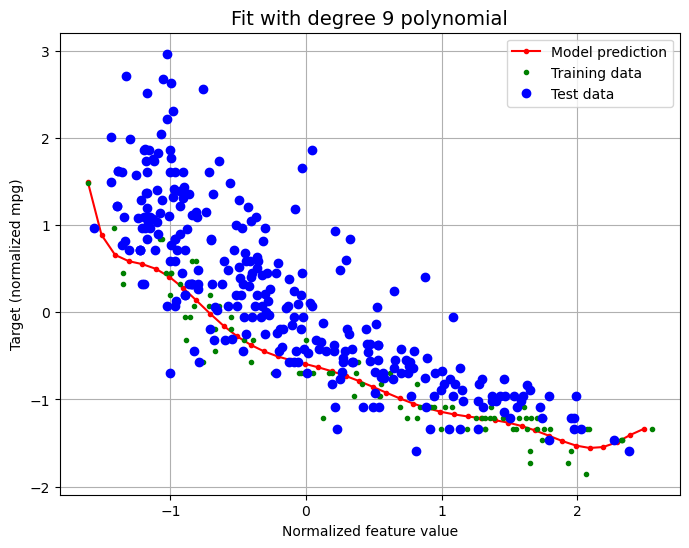

In [15]:
    # 4) 1D visualizations

# degree 1 
phi_train_1 = design_matrix_polynomial(x_train[:,[3]], 1)
w_1 = ols_solution(phi_train_1, t_train)
visualize_1d(x_n[:,3],t_n,1,w_1,x_train_idx=100)

# degree 3
phi_test_3 = design_matrix_polynomial(x_train[:,[3]], 3)
w_3 = ols_solution(phi_test_3, t_train)
visualize_1d(x_n[:,3],t_n,3,w_3,x_train_idx=100)

# degree 9 
phi_train_9 = design_matrix_polynomial(x_train[:,[3]], 9)
w_9 = ols_solution(phi_train_9, t_train)
visualize_1d(x_n[:,3],t_n,9,w_9,x_train_idx=100)
                   

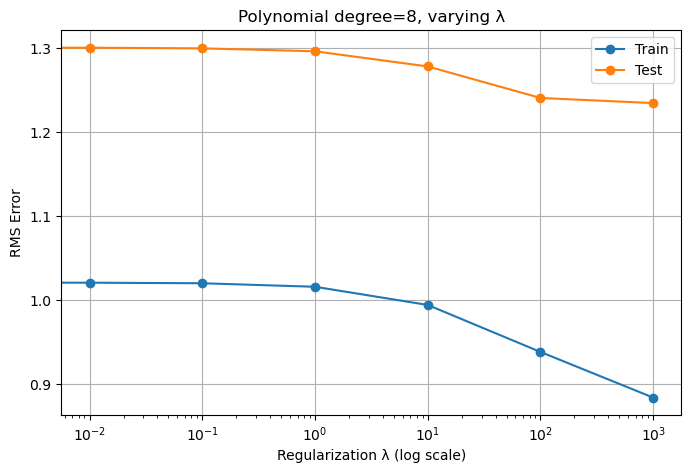

In [16]:
    # 5) L2 regularization on degree 8 with feature 3 only
degree = 8
lambdas = [0, 0.01, 0.1, 1, 10, 100, 1000]
w_result = []
train_err = []
test_err = []
    

phi_train_8 = design_matrix_polynomial(x_train[:,[3]], 8)
phi_test_8 = design_matrix_polynomial(x_test[:,[3]], 8)

for lam in lambdas:
    # w with regularization
    w = ridge_solution(phi_train_8, t_train, lam)
    w_result.append(w)
    
    y_test = predict(phi_test_8, w)
    y_train = predict(phi_train_8, w)
    
    rms_train = rms_error(t_train, y_train)
    rms_test = rms_error(t_test, y_test)
    
    train_err.append(rms_train)
    test_err.append(rms_test)
    
    
plt.figure(figsize=(8,5))
plt.semilogx(lambdas, train_err, '-o', label='Train')
plt.semilogx(lambdas, test_err, '-o', label='Test')
plt.xlabel('Regularization λ (log scale)')
plt.ylabel('RMS Error')
plt.title('Polynomial degree=8, varying λ')
plt.legend()
plt.grid(True)
plt.show()

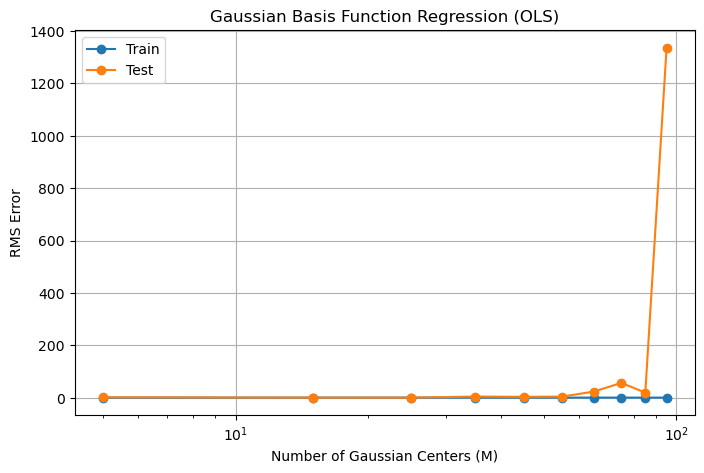

In [17]:
    # 6) Gaussian basis experiments (varying number of centers)
M = [5,15,25,35,45,55,65,75,85,95]
w_gaussian_result =[]
train_gaussian_err = []
test_gaussian_err = []
s = 2.0
for m in M :
    idx = np.random.choice(x_train.shape[0], m , replace=False)
    centers = x_train[idx,:]
    phi_train = design_matrix_gaussian(x_train,centers,s)
    w = ols_solution(phi_train, t_train)
    w_gaussian_result.append(w)
    
    phi_test = design_matrix_gaussian(x_test,centers,m)
    
    y_train = predict(phi_train, w)  
    y_test = predict(phi_test, w)

    rms_train = rms_error(t_train, y_train)
    rms_test = rms_error(t_test, y_test)
    
    train_gaussian_err.append(rms_train)
    test_gaussian_err.append(rms_test)

    
    
plt.figure(figsize=(8,5))
plt.semilogx(M, train_gaussian_err, '-o', label='Train')
plt.semilogx(M, test_gaussian_err, '-o', label='Test')
plt.xlabel('Number of Gaussian Centers (M)')
plt.ylabel('RMS Error')
plt.title('Gaussian Basis Function Regression (OLS)')
plt.legend()
plt.grid(True)
plt.show()

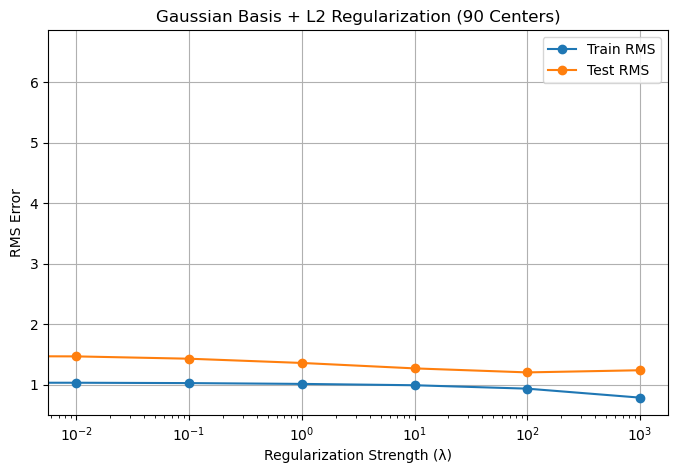

In [19]:
    # 7) Gaussian + L2 with 90 bases using all features

lambdas = [0, 0.01, 0.1, 1, 10, 100, 1000]
w_gaussian_90_result =[]
train_gaussian_90_err = []
test_gaussian_90_err = []
s = 2.0
m = 90

idx = np.random.choice(x_train.shape[0], m , replace=False)
centers = x_train[idx,:]
phi_train_90 = design_matrix_gaussian(x_train,centers,s)
phi_test_90 = design_matrix_gaussian(x_test,centers,s)


for lam in lambdas:
    # ridge regression
    w = ridge_solution(phi_train_90, t_train, lam)
    w_gaussian_90_result.append(w)
    
    # predict train and test
    y_test = predict(phi_test_90, w)
    y_train = predict(phi_train_90, w)
    
    rms_train = rms_error(t_train, y_train)
    rms_test = rms_error(t_test, y_test)
    
    train_gaussian_90_err.append(rms_train)
    test_gaussian_90_err.append(rms_test)    

plt.figure(figsize=(8,5))
plt.semilogx(lambdas, train_gaussian_90_err, '-o', label='Train RMS')
plt.semilogx(lambdas, test_gaussian_90_err, '-o', label='Test RMS')
plt.xlabel('Regularization Strength (λ)')
plt.ylabel('RMS Error')
plt.title('Gaussian Basis + L2 Regularization (90 Centers)')
plt.legend()
plt.grid(True)
plt.show()
